# Analisis Pendanaan Startup Teknologi Menggunakan Python

## Disusun oleh: Fatur Rachman

## Tujuan

Project ini bertujuan untuk menganalisis data pendanaan startup teknologi menggunakan Python. Analisis dilakukan untuk mengetahui tren pendanaan, distribusi investasi, serta sektor dan wilayah yang paling banyak menerima pendanaan. Hasil analisis disajikan dalam bentuk tabel dan visualisasi data sebagai dasar untuk memperoleh insight bisnis.

In [1]:
# Import library yang dibutuhkan
import pandas as pd
import matplotlib.pyplot as plt

# Mengatur gaya visualisasi
plt.style.use('ggplot')

ModuleNotFoundError: No module named 'pandas'

In [2]:
import sys
print(sys.executable)

C:\Users\USER\AppData\Local\Programs\Python\Python314\python.exe


In [3]:
%pip install pandas matplotlib openpyxl

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.8 MB 9.4 MB/s eta 0:00:01
   ----------- ---------------------------- 2.9/9.8 MB 6.9 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.8 MB 6.4 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.8 MB 6.4 MB/s eta 0:00:01
   ------------------------- -------------- 6.3/9.8 MB 6.1 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.8 MB 5.9 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.8 MB 5.8 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.8 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 5.7 MB/s  0:00:01
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.5 MB 6.1 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.5 MB 6.1 MB/s eta 0:00:02
   --------------- ----------

In [4]:
!python -m pip install pandas matplotlib openpyxl

In [5]:
import sys
!{sys.executable} -m pip install pandas matplotlib openpyxl

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("tech_fundings.csv")

In [3]:
df.head()

,index,Company,Website,Region,Vertical,Funding Amount (USD),Funding Stage,Funding Date
0,1,Internxt,https://internxt.com/,Spain,Blockchain,278940,Seed,Jan-20
1,2,Dockflow,https://dockflow.com,Belgium,Logistics,292244,Seed,Jan-20
2,3,api.video,https://api.video,France,Developer APIs,300000,Seed,Jan-20
3,4,Buck.ai,https://buck.ai/,United States,Artificial Intelligence,300000,Seed,Jan-20
4,5,Prodsight,https://www.prodsight.ai,United Kingdom,Artificial Intelligence,529013,Seed,Jan-20


## 1. Memahami Dataset

Tahap pertama adalah memahami struktur dataset. Proses ini dilakukan untuk mengetahui jumlah data, nama kolom, tipe data, serta memastikan dataset telah berhasil dimuat.

In [5]:
df.shape

(3575, 8)

In [6]:
df.columns

Index(['index', 'Company', 'Website', 'Region', 'Vertical',
       'Funding Amount (USD)', 'Funding Stage', 'Funding Date'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3575 entries, 0 to 3574
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   index                 3575 non-null   int64
 1   Company               3575 non-null   str  
 2   Website               3575 non-null   str  
 3   Region                3563 non-null   str  
 4   Vertical              3575 non-null   str  
 5   Funding Amount (USD)  3575 non-null   str  
 6   Funding Stage         3575 non-null   str  
 7   Funding Date          3575 non-null   str  
dtypes: int64(1), str(7)
memory usage: 223.6 KB


In [8]:
df.describe()

,index
count,3575.000000
mean,1788.000000
std,1032.157934
min,1.000000
25%,894.500000
50%,1788.000000
75%,2681.500000
max,3575.000000


In [9]:
df.isnull().sum()

index                    0
Company                  0
Website                  0
Region                  12
Vertical                 0
Funding Amount (USD)     0
Funding Stage            0
Funding Date             0
dtype: int64

# 2. Data Cleaning

Tahap ini bertujuan untuk membersihkan dataset agar siap dianalisis. Proses yang dilakukan meliputi:

- Menghapus kolom yang tidak diperlukan.
- Mengecek data duplikat.
- Menangani missing value.
- Mengubah tipe data agar sesuai.

In [10]:
df = df.drop(columns=["index"])

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
# Menghapus baris yang memiliki nilai kosong
df = df.dropna()

In [13]:
df.isnull().sum()

Company                 0
Website                 0
Region                  0
Vertical                0
Funding Amount (USD)    0
Funding Stage           0
Funding Date            0
dtype: int64

In [14]:
df["Funding Amount (USD)"].head(10)

0     278940
1     292244
2     300000
3     300000
4     529013
5     650000
6     970000
7    1000000
8    1000000
9    1100000
Name: Funding Amount (USD), dtype: str

Index(['Company', 'Website', 'Region', 'Vertical', 'Funding Amount (USD)',
       'Funding Stage', 'Funding Date'],
      dtype='str')

In [17]:
df.columns.duplicated().sum()

np.int64(0)

In [18]:
type(df["Funding Amount (USD)"])

pandas.Series

In [19]:
df["Funding Amount (USD)"].tail(20)

3555      250000000
3556      100000000
3557        2500000
3558      100000000
3559       50000000
3560      500000000
3561        6988982
3562       70000000
3563        7000000
3564       54744033
3565       43334400
3566    16600000000
3567       24896631
3568        4113750
3569        9500000
3570       12000000
3571       43000000
3572        2737468
3573       70000000
3574        2953675
Name: Funding Amount (USD), dtype: str

In [20]:
type(df["Funding Amount (USD)"])

pandas.Series

In [21]:
df["Funding Amount (USD)"].apply(type).value_counts()

Funding Amount (USD)
<class 'str'>    3563
Name: count, dtype: int64

In [22]:
df["Funding Amount (USD)"] = pd.to_numeric(
    df["Funding Amount (USD)"],
    errors="coerce"
)

In [23]:
df["Funding Amount (USD)"].isna().sum()

np.int64(9)

In [24]:
df[df["Funding Amount (USD)"].isna()]

,Company,Website,Region,Vertical,Funding Amount (USD),Funding Stage,Funding Date
1262,Mobilewalla,https://www.mobilewalla.com/,United States,B2B Software,NaN,Seed,Nov-20
1263,Hypotenuse,https://hypotenuse.ai/,United States,B2B Software,NaN,Seed,Nov-20
1264,DropSuite,https://dropsuite.com,Singapore,B2B Software,NaN,Seed,Nov-20
1284,Pensando,https://www.pensando.io/,United States,Cloud Computing,NaN,Unknown,Nov-20
1285,Azion,https://www.azion.com,United States,Cloud Computing,NaN,Unknown,Nov-20
1293,Digify,https://www.digify.com,United States,Cyber Security,NaN,Seed,Nov-20
1301,Unacademy,https://unacademy.com/,India,Education,NaN,Unknown,Nov-20
1310,Level,https://www.levelgoals.com/,United States,Finance,NaN,Grant,Nov-20
1327,Push Party,https://pushparty.app/,United States,Social Network,NaN,Seed,Nov-20


In [25]:
df = df.dropna(subset=["Funding Amount (USD)"])

In [26]:
df["Funding Amount (USD)"] = df["Funding Amount (USD)"].astype(int)

df.info()

# 3. Exploratory Data Analysis

Pada tahap ini dilakukan analisis eksploratif untuk mengetahui pola pendanaan startup berdasarkan perusahaan, wilayah, sektor industri, dan tahap pendanaan.

In [29]:
top_company = df.sort_values(
    by="Funding Amount (USD)",
    ascending=False
).head(10)

top_company

,Company,Website,Region,Vertical,Funding Amount (USD),Funding Stage,Funding Date
3566,WestConnex,https://www.westconnex.com.au/,Australia,Transportation,16600000000,Private Equity,Sep-21
797,SpaceX,https://www.spacex.com/,United States,Aerospace,1901446920,Unknown,Aug-20
3048,Databricks,https://databricks.com,United States,Artificial Intelligence,1600000000,Series H,Aug-21
2925,Articulate,https://www.articulate.com,United States,Education,1500000000,Series A,Jul-21
96,Gojek,https://www.gojek.io/,Indonesia,Food Delivery,1200000000,Series G,Mar-20
1996,Gopuff,https://www.gopuff.com,United States,Transportation,1150000000,Series G,Mar-21
2609,Celonis,https://www.celonis.com,Germany,Cloud Computing,1000000000,Series D,Jun-21
2489,Trade Republic,https://traderepublic.com,Germany,Investing,900000000,Series C,May-21
2833,FTX Exchange,https://ftx.com/,United States,Blockchain,900000000,Series B,Jul-21
2948,Revolut,https://www.revolut.com,United Kingdom,Finance,800000000,Series E,Jul-21


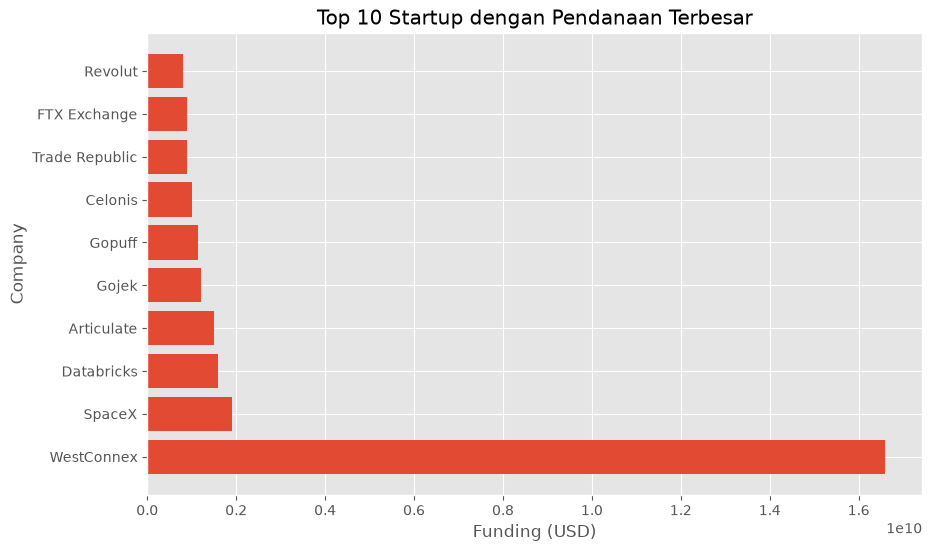

In [30]:
plt.figure(figsize=(10,6))

plt.barh(
    top_company["Company"],
    top_company["Funding Amount (USD)"]
)

plt.title("Top 10 Startup dengan Pendanaan Terbesar")
plt.xlabel("Funding (USD)")
plt.ylabel("Company")

plt.show()

In [31]:
region = df.groupby("Region")["Funding Amount (USD)"].sum()

region = region.sort_values(ascending=False)

region

Region
United States     117549449595
Australia          18389305745
United Kingdom     11544890932
India               9099459928
Germany             8424126353
                      ...     
Armenia                1750000
Belize                 1450000
Romania                1320789
Senegal                1200000
Ghana                   700000
Name: Funding Amount (USD), Length: 72, dtype: int64

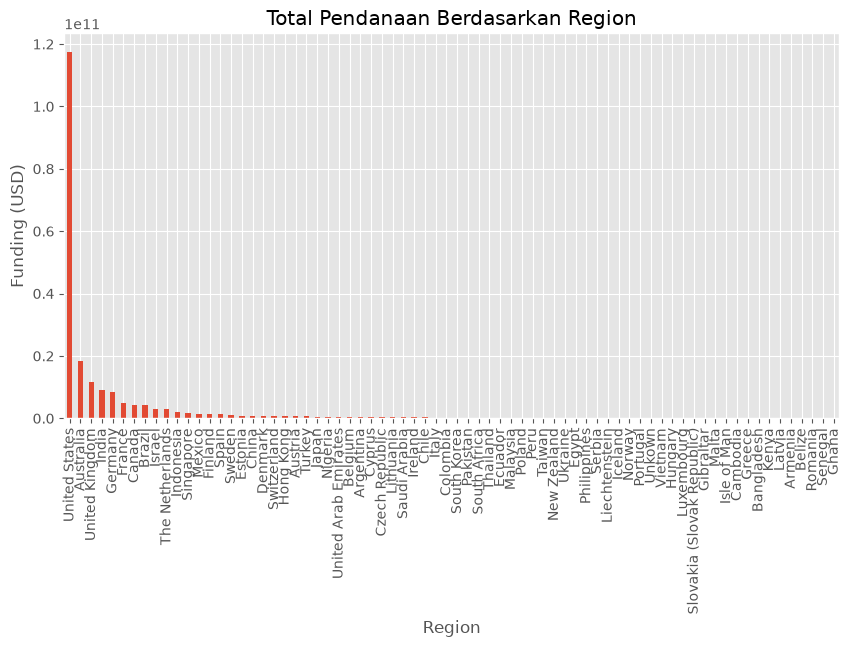

In [32]:
plt.figure(figsize=(10,5))

region.plot(kind="bar")

plt.title("Total Pendanaan Berdasarkan Region")
plt.xlabel("Region")
plt.ylabel("Funding (USD)")

plt.show()

In [33]:
stage = df["Funding Stage"].value_counts()

stage

Funding Stage
Series A                 950
Seed                     837
Series B                 650
Series C                 463
Series D                 249
Series E                 135
Series F                  62
Unknown                   61
Pre-Seed                  57
Series G                  26
Private Equity            21
Angel                     14
Debt Financing            12
ICO                        5
Series H                   4
Crowdfunding               3
Initial Coin Offering      1
Unkown                     1
Undisclosed                1
Funding                    1
Growth                     1
Name: count, dtype: int64

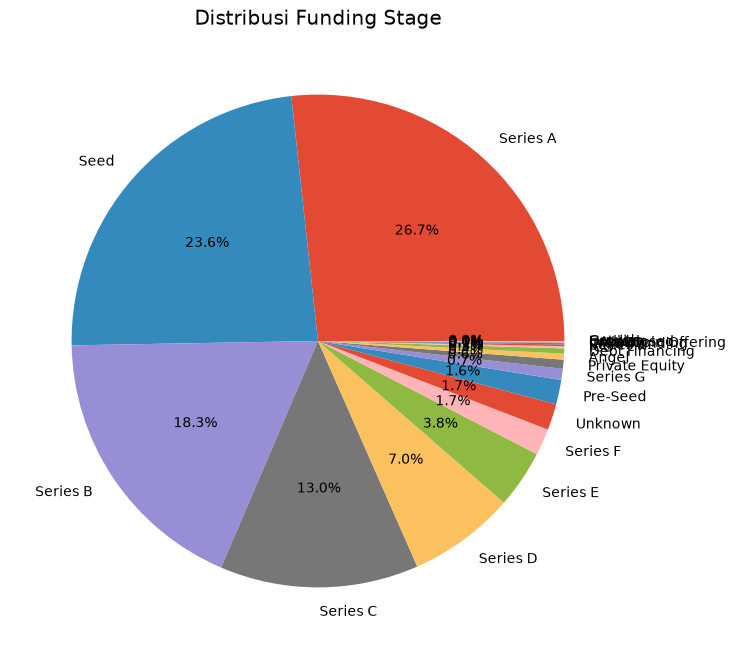

In [34]:
plt.figure(figsize=(8,8))

plt.pie(
    stage,
    labels=stage.index,
    autopct="%1.1f%%"
)

plt.title("Distribusi Funding Stage")

plt.show()

In [35]:
vertical = df.groupby("Vertical")["Funding Amount (USD)"].sum()

vertical = vertical.sort_values(ascending=False).head(10)

vertical

Vertical
B2B Software               24073597899
Transportation             19817448858
Finance                    19652523655
Cloud Computing            16580834686
Artificial Intelligence    13280076886
Health Care                10129144662
Blockchain                  7447977494
Food and Beverage           6899785865
Cyber Security              6732944085
Education                   6395730595
Name: Funding Amount (USD), dtype: int64

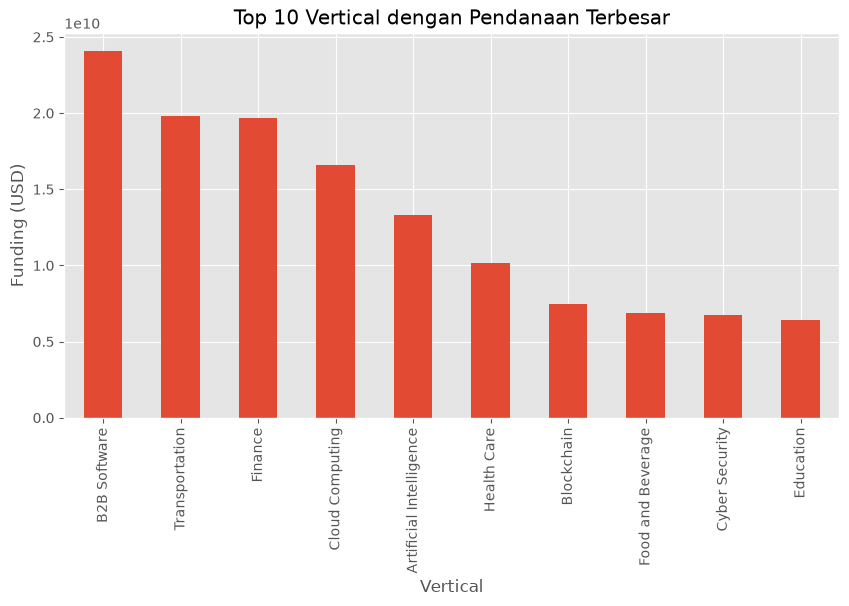

In [36]:
plt.figure(figsize=(10,5))

vertical.plot(kind="bar")

plt.title("Top 10 Vertical dengan Pendanaan Terbesar")
plt.xlabel("Vertical")
plt.ylabel("Funding (USD)")

plt.show()

df["Funding Date"] = pd.to_datetime(df["Funding Date"])

In [39]:
df["Year"] = df["Funding Date"].dt.year

In [40]:
year = df.groupby("Year")["Funding Amount (USD)"].sum()

year

Year
1    205217462802
Name: Funding Amount (USD), dtype: int64

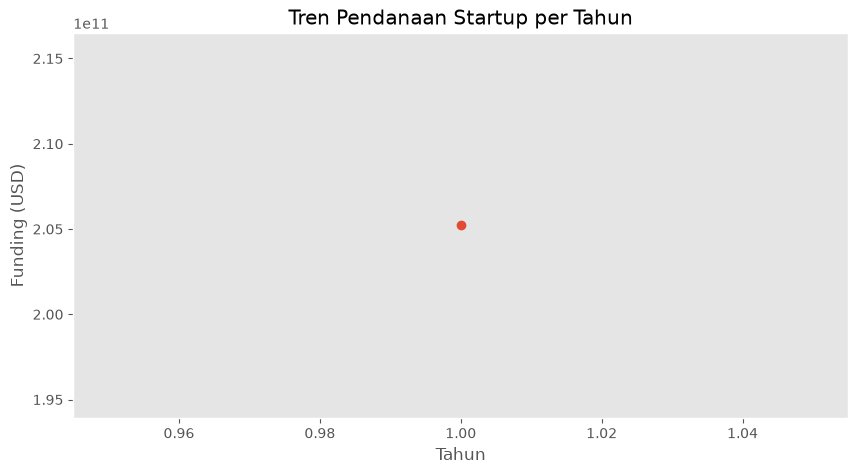

In [41]:
plt.figure(figsize=(10,5))

plt.plot(
    year.index,
    year.values,
    marker="o"
)

plt.title("Tren Pendanaan Startup per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Funding (USD)")

plt.grid()

plt.show()

# 4. Kesimpulan

Berdasarkan hasil analisis dapat disimpulkan bahwa:

- Startup tertentu memperoleh pendanaan paling tinggi dibandingkan perusahaan lain.
- Beberapa region menjadi pusat pendanaan startup teknologi.
- Tahap pendanaan tertentu lebih mendominasi dibandingkan tahap lainnya.
- Industri (vertical) tertentu lebih banyak menarik investor.
- Tren pendanaan berubah dari tahun ke tahun sehingga dapat menjadi indikator perkembangan ekosistem startup.